## **Modelos Deep Learning em PyTorch**

**Tarefa 3 do Trabalho Prático — Aprendizagem Profunda**

1. **DNNs** — Feedforward com features tabulares, variando largura
2. **Embedding + DNN** — Embedding treinável, variando dimensão do embedding
3. **BiLSTM** — LSTM bidirecional, variando dimensão do hidden state
4. **BiGRU** — Alternativa ao LSTM (comparação LSTM vs GRU)
5. **BiLSTM + GloVe** — Embeddings pré-treinados, frozen vs fine-tuned
6. **Stratified K-Fold (K=5)** — Comparação robusta
7. **Retreino e avaliação final** no dataset do professor

### **1. Imports e Configuração**

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time, re
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

sys.path.append(os.path.abspath('../src'))
from utils import (prepare_text_data, prepare_fold_data, transform_new_texts,
                    clean_text, stratified_k_fold)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Dispositivo: cuda


### **2. Carregamento dos Dados**

In [ ]:
print('A carregar os datasets...')

df_main = pd.read_csv('../data/dataset.csv', sep=';')
df_main.columns = df_main.columns.str.lower()
textos = df_main['text'].tolist()
labels = df_main['label'].tolist()

df_test = pd.read_csv('../data/dataset-exemplos.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

class_names_list = sorted(set(labels))
num_classes = len(class_names_list)

print(f'  Dataset principal: {len(textos)} textos')
print(f'  Dataset teste (prof): {len(textos_test)} textos')
print(f'  Classes: {class_names_list}')

A carregar os datasets...
  Dataset principal: 5000 textos
  Dataset teste (prof): 125 textos
  Classes: ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']


### **3. Definição dos Modelos**

Cada família tem duas variantes, explorando o hiperparâmetro mais relevante:

| Família | Variantes | Hiperparâmetro explorado |
|---------|-----------|--------------------------|
| **DNN (tabular)** | Wide (256→128), Narrow (128→64), Deep (256→128→64) | Largura e profundidade |
| **DNN (ativação)** | ReLU vs LeakyReLU vs ELU (256→128) | Função de ativação |
| **Embedding + DNN** | embed 64d, embed 128d | Dimensão do embedding |
| **BiLSTM** | hidden 64, hidden 128 | Dimensão do hidden state |
| **BiGRU** | hidden 64, hidden 128 | LSTM vs GRU + hidden size |
| **BiLSTM + GloVe** | frozen, fine-tuned | Congelar vs ajustar embeddings |

Todos os modelos sequenciais usam o mesmo classificador (128→64→classes) para comparação justa.

In [25]:
# ══════════════════════════════════════
# DNNs tabulares
# ══════════════════════════════════════

class DNNWide(nn.Module):
    """256 → 128 → classes"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)

class DNNNarrow(nn.Module):
    """128 → 64 → classes"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, num_classes))
    def forward(self, x): return self.net(x)

# ══════════════════════════════════════
# Embedding + DNN — varia dimensão do embedding
# Classificador fixo: 128 → 64 → classes
# ══════════════════════════════════════

class EmbeddingDNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, num_classes))
    def forward(self, x):
        embedded = self.embedding(x)
        mask = (x != 0).unsqueeze(-1).float()
        pooled = (embedded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return self.net(pooled)

# ══════════════════════════════════════
# BiLSTM — varia hidden_dim
# ══════════════════════════════════════

class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

# ══════════════════════════════════════
# BiGRU — alternativa ao LSTM, varia hidden_dim
# ══════════════════════════════════════

class BiGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, hidden = self.gru(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

# ══════════════════════════════════════
# BiLSTM + GloVe — varia frozen vs fine-tuned
# ══════════════════════════════════════

class BiLSTMGloVe(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, freeze_embed=True):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.freeze_embed = freeze_embed
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_embed, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, num_classes))
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        combined = torch.cat([hidden[-2], hidden[-1]], dim=1)
        return self.fc(self.dropout(combined))

class DNNDeep(nn.Module):
    """256 → 128 → 64 → classes (mais profunda, ReLU)"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes))
    def forward(self, x): return self.net(x)
class DNNLeakyReLU(nn.Module):
    """256 → 128 → classes (LeakyReLU)"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.1), nn.Dropout(0.4),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)
class DNNELU(nn.Module):
    """256 → 128 → classes (ELU)"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ELU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ELU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)

class DNNSimple(nn.Module):
    """128 → 32 → classes (simples, ReLU + Dropout)"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(32, num_classes))
    def forward(self, x): return self.net(x)

class DNNVeryDeep(nn.Module):
    """256 → 128 → 64 → 32 → classes"""
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, num_classes))
    def forward(self, x): return self.net(x)


print('Modelos definidos.')

Modelos definidos.


### **4. Validação Cruzada — Stratified K-Fold (K=5)**

Para cada fold, TF-IDF e vocabulários são ajustados apenas no treino.

In [26]:
K = 5
FEAT_PARAMS = dict(max_features=1500, char_features=1500, ngram_range=(1, 2), stop_words=set())
EMBED_DIM_DEFAULT = 64
HIDDEN_DIM_DEFAULT = 64
MAX_SEQ_LEN = 150
VOCAB_SIZE = 10000
GLOVE_DIM = 100
GLOVE_HIDDEN = 128

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return [t for t in text.split() if len(t) > 1]

def texts_to_sequences(texts, word2idx, max_len):
    seqs = []
    for text in texts:
        tokens = simple_tokenize(text)
        seq = [word2idx.get(t, 1) for t in tokens[:max_len]]
        seqs.append(seq + [0] * (max_len - len(seq)))
    return np.array(seqs)

def build_fold_vocab(texts_tr):
    wc = Counter()
    for t in texts_tr: wc.update(simple_tokenize(t))
    mc = wc.most_common(VOCAB_SIZE - 2)
    w2i = {w: i+2 for i, (w, _) in enumerate(mc)}
    w2i['<PAD>'] = 0; w2i['<UNK>'] = 1
    return w2i

def train_pytorch(model, X_tr, y_tr, X_vl, y_vl,
                  epochs=100, lr=0.001, wd=1e-3, patience=10, bs=128):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=5)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=bs, shuffle=True)
    best_vl = float('inf'); wait = 0; best_st = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for ep in range(epochs):
        model.train()
        ep_loss = 0; ep_correct = 0; ep_total = 0
        for bx, by in loader:
            opt.zero_grad()
            out = model(bx)
            loss = crit(out, by)
            loss.backward(); opt.step()
            ep_loss += loss.item() * bx.size(0)
            ep_correct += (torch.argmax(out, 1) == by).sum().item()
            ep_total += bx.size(0)
        history['train_loss'].append(ep_loss / ep_total)
        history['train_acc'].append(ep_correct / ep_total)
        model.eval()
        with torch.no_grad():
            val_out = model(X_vl)
            vl = crit(val_out, y_vl).item()
            va = (torch.argmax(val_out, 1) == y_vl).float().mean().item()
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        sched.step(vl)
        if vl < best_vl:
            best_vl = vl; wait = 0
            best_st = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_st: model.load_state_dict(best_st)
    model.eval()
    with torch.no_grad():
        final_acc = (torch.argmax(model(X_vl), 1) == y_vl).float().mean().item()
    return final_acc, history

def plot_training_curves(nome, all_histories):
    """Plota curvas de treino médias dos K folds."""
    min_len = min(len(h['train_loss']) for h in all_histories)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for (tk, vk), ax, title in [
        (('train_loss', 'val_loss'), axes[0], 'Loss'),
        (('train_acc', 'val_acc'), axes[1], 'Accuracy')
    ]:
        t_vals = np.array([h[tk][:min_len] for h in all_histories])
        v_vals = np.array([h[vk][:min_len] for h in all_histories])
        epochs_range = range(1, min_len + 1)
        ax.plot(epochs_range, t_vals.mean(axis=0), label='Train', linewidth=2)
        ax.plot(epochs_range, v_vals.mean(axis=0), label='Val', linewidth=2)
        ax.fill_between(epochs_range,
                        t_vals.mean(0) - t_vals.std(0),
                        t_vals.mean(0) + t_vals.std(0), alpha=0.15)
        ax.fill_between(epochs_range,
                        v_vals.mean(0) - v_vals.std(0),
                        v_vals.mean(0) + v_vals.std(0), alpha=0.15)
        ax.set_xlabel('Epoch'); ax.set_ylabel(title)
        ax.set_title(f'{nome} — {title}')
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
def kfold_seq(nome, model_fn):
    print(f'\n{nome}:')
    accs = []; histories = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        w2i = build_fold_vocab(t_tr); vs = len(w2i)
        s_tr = texts_to_sequences(t_tr, w2i, MAX_SEQ_LEN)
        s_vl = texts_to_sequences(t_vl, w2i, MAX_SEQ_LEN)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc, hist = train_pytorch(
            model_fn(vs, num_classes),
            torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl).to(device),
            wd=1e-4, patience=10)
        accs.append(acc); histories.append(hist)
        print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')
    plot_training_curves(nome, histories)

print('Funções definidas.')

Funções definidas.


In [27]:
import zipfile, urllib.request
GLOVE_DIR = './data/glove'
GLOVE_PATH = os.path.join(GLOVE_DIR, f'glove.6B.{GLOVE_DIM}d.txt')
if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    zip_path = os.path.join(GLOVE_DIR, 'glove.6B.zip')
    if not os.path.exists(zip_path):
        print('A descarregar GloVe 6B (822MB)...')
        urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', zip_path)
    print('A extrair...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract(f'glove.6B.{GLOVE_DIM}d.txt', GLOVE_DIR)
else:
    print(f'GloVe já disponível em {GLOVE_PATH}')
print(f'A carregar GloVe {GLOVE_DIM}d...')
glove_all = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        glove_all[parts[0]] = np.array(parts[1:], dtype=np.float32)
print(f'✅ GloVe: {len(glove_all)} vetores')

def build_emb_matrix(w2i, glove, dim):
    mat = np.random.normal(scale=0.6, size=(len(w2i), dim))
    mat[0] = 0; found = 0
    for w, i in w2i.items():
        if w in glove: mat[i] = glove[w]; found += 1
    return mat, found

GloVe já disponível em ./data/glove\glove.6B.100d.txt
A carregar GloVe 100d...
✅ GloVe: 400000 vetores


Stratified 5-Fold Cross-Validation

DNN Wide (256→128):
  Fold 1: 84.70%
  Fold 2: 83.10%
  Fold 3: 85.60%
  Fold 4: 84.90%
  Fold 5: 85.40%
  → 84.74% ± 0.88%


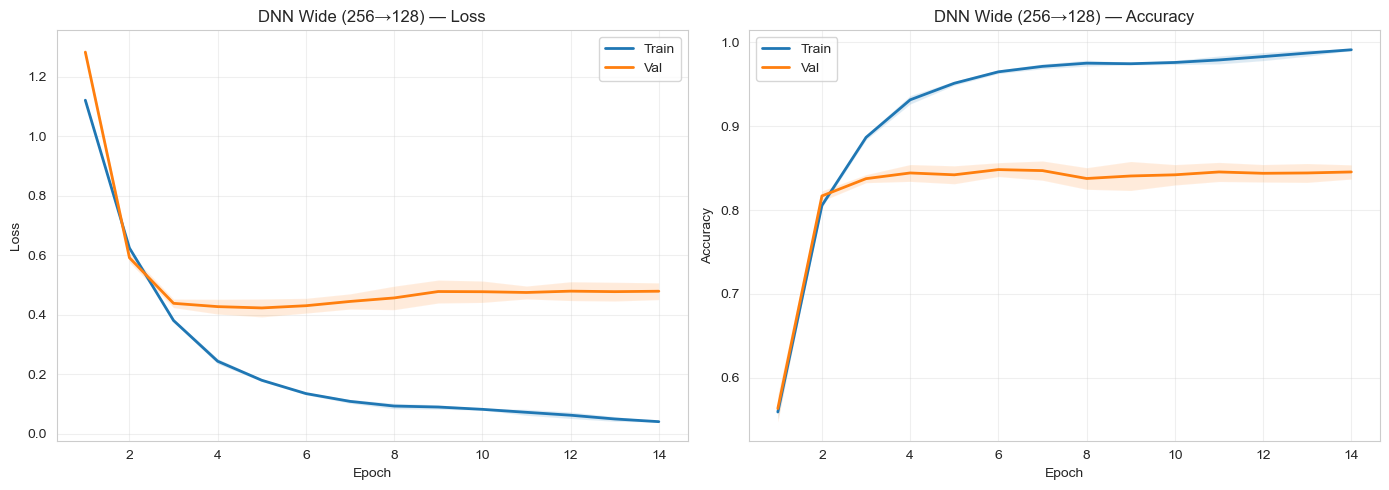


DNN Narrow (128→64):
  Fold 1: 83.60%
  Fold 2: 83.40%
  Fold 3: 85.70%
  Fold 4: 85.40%
  Fold 5: 84.90%
  → 84.60% ± 0.94%


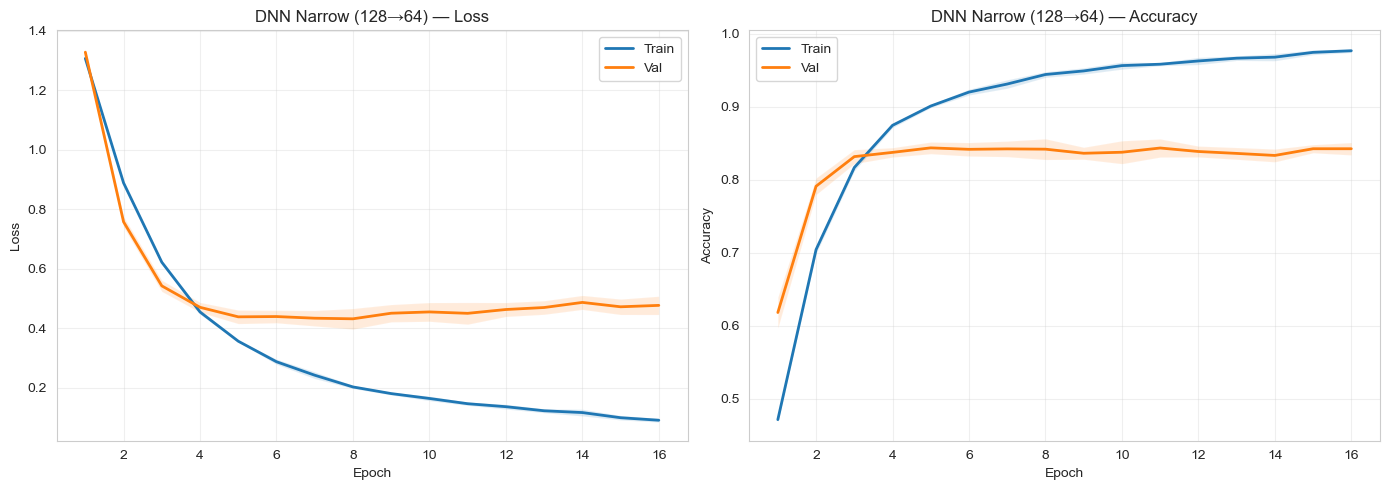


DNN Deep (256→128→64):
  Fold 1: 85.00%
  Fold 2: 83.90%
  Fold 3: 84.90%
  Fold 4: 84.20%
  Fold 5: 83.20%
  → 84.24% ± 0.67%


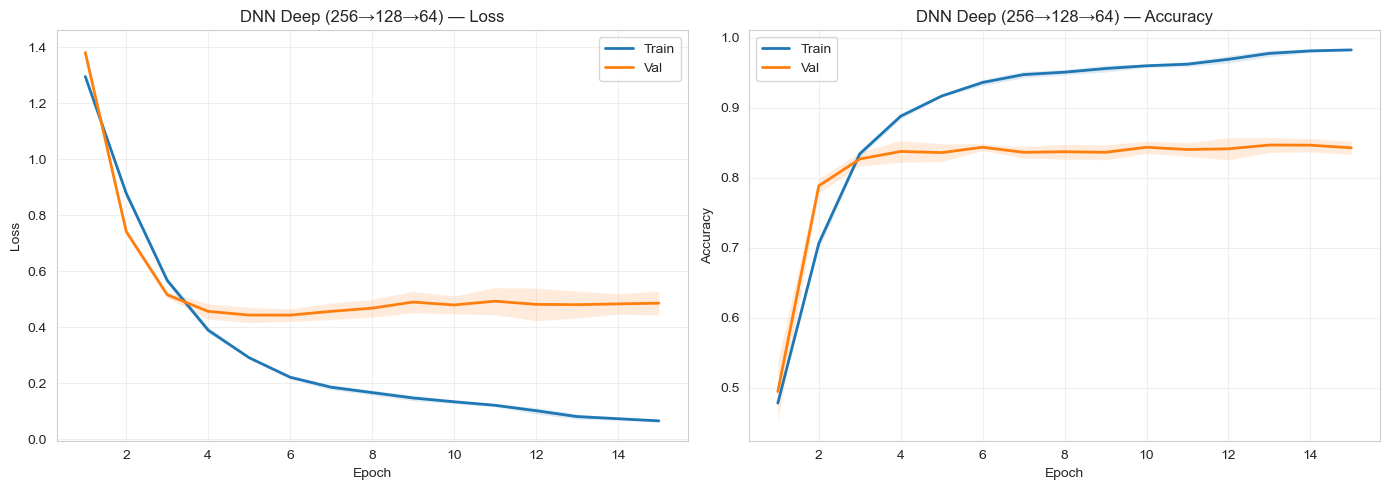


DNN Simple (128→32):
  Fold 1: 83.80%
  Fold 2: 83.30%
  Fold 3: 85.90%
  Fold 4: 85.60%
  Fold 5: 83.60%
  → 84.44% ± 1.09%


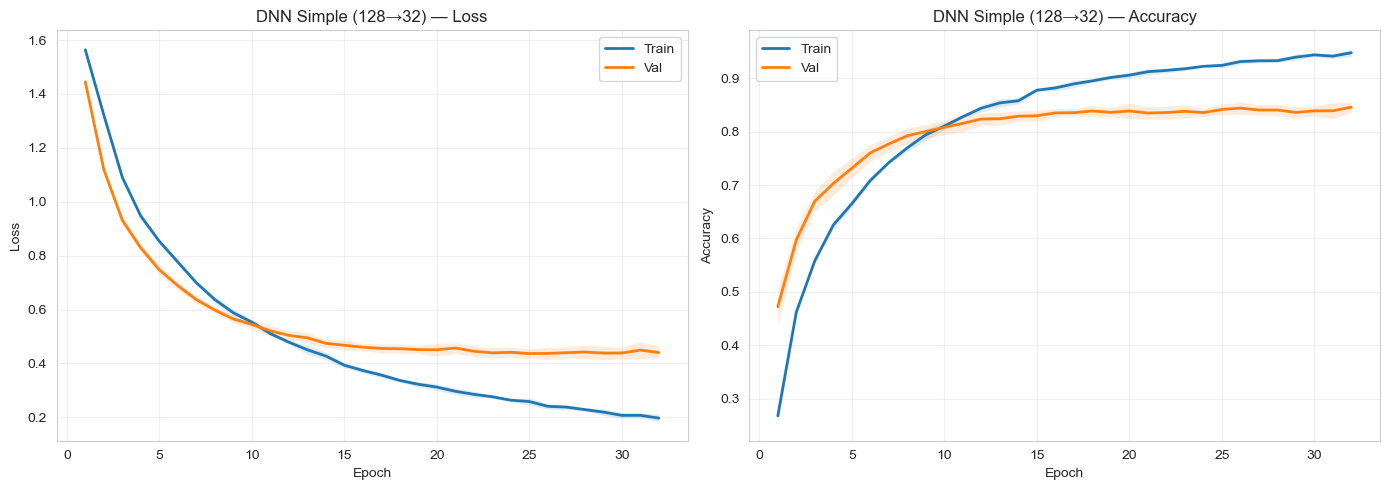


DNN VeryDeep (256→128→64→32):
  Fold 1: 83.00%
  Fold 2: 83.30%
  Fold 3: 85.60%
  Fold 4: 85.10%
  Fold 5: 83.10%
  → 84.02% ± 1.10%


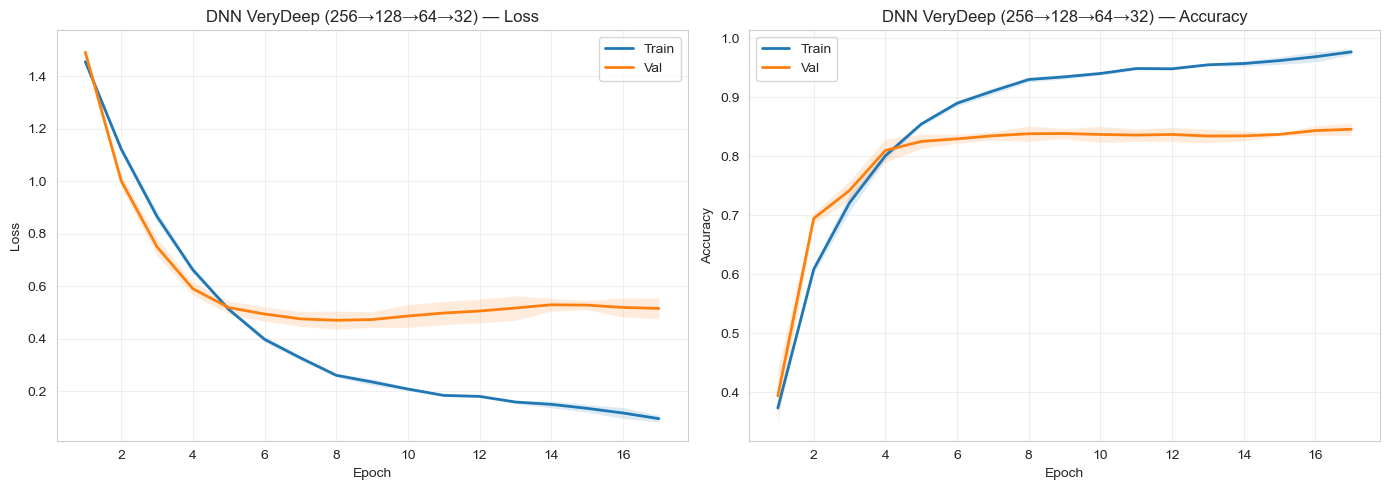


DNN LeakyReLU (256→128):
  Fold 1: 84.30%
  Fold 2: 84.40%
  Fold 3: 86.70%
  Fold 4: 85.20%
  Fold 5: 85.20%
  → 85.16% ± 0.86%


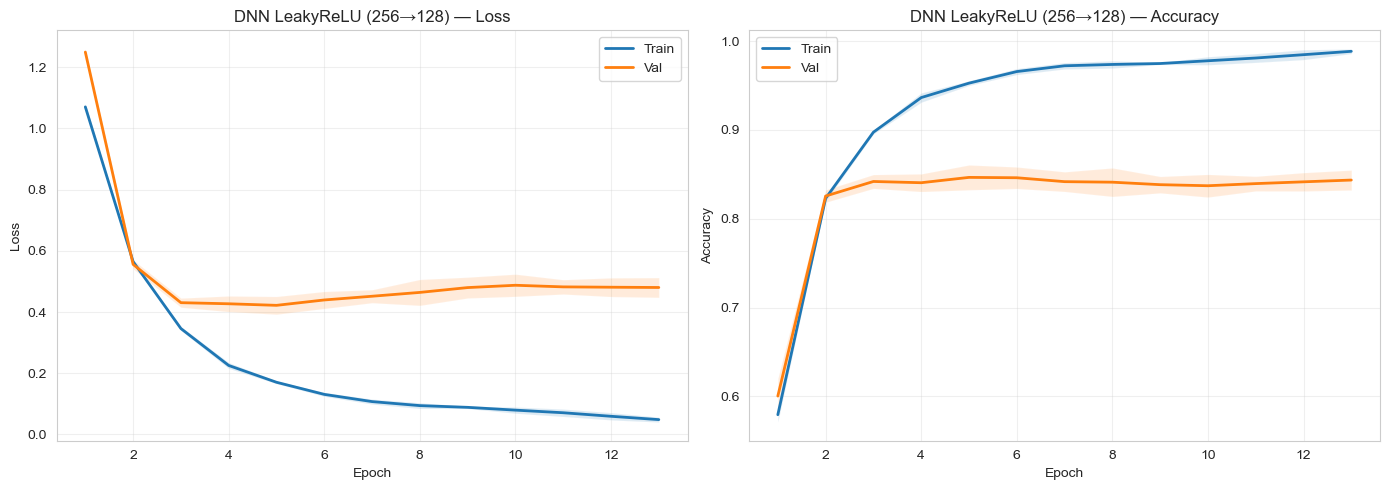


DNN ELU (256→128):
  Fold 1: 83.00%
  Fold 2: 83.70%
  Fold 3: 85.70%
  Fold 4: 84.20%
  Fold 5: 83.30%
  → 83.98% ± 0.95%


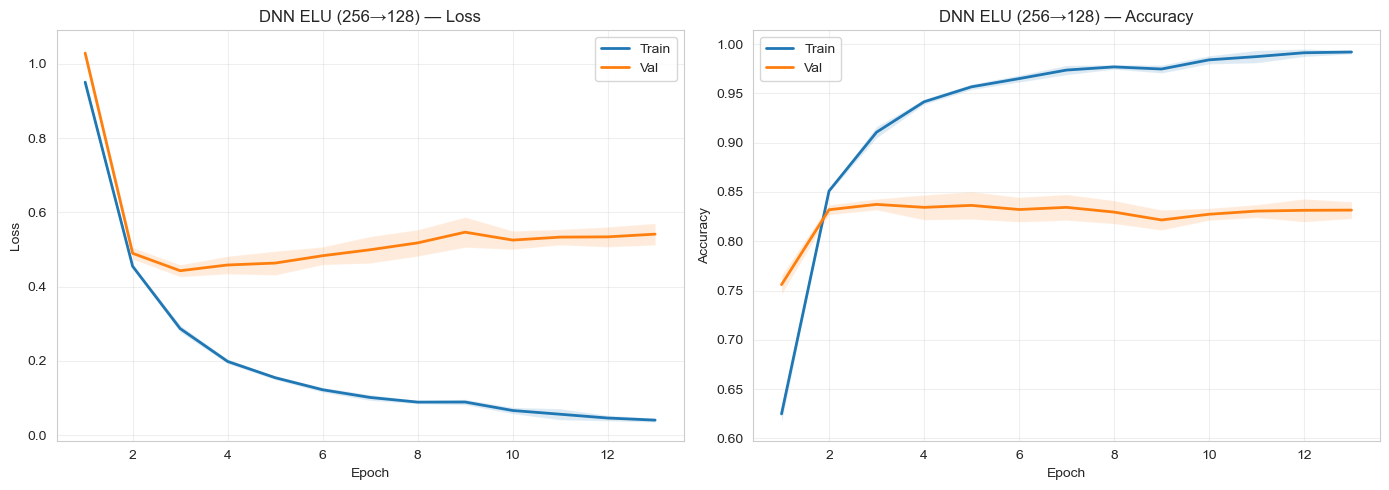


Embed+DNN (64d):
  Fold 1: 70.40%
  Fold 2: 69.70%
  Fold 3: 67.90%
  Fold 4: 71.50%
  Fold 5: 68.80%
  → 69.66% ± 1.25%


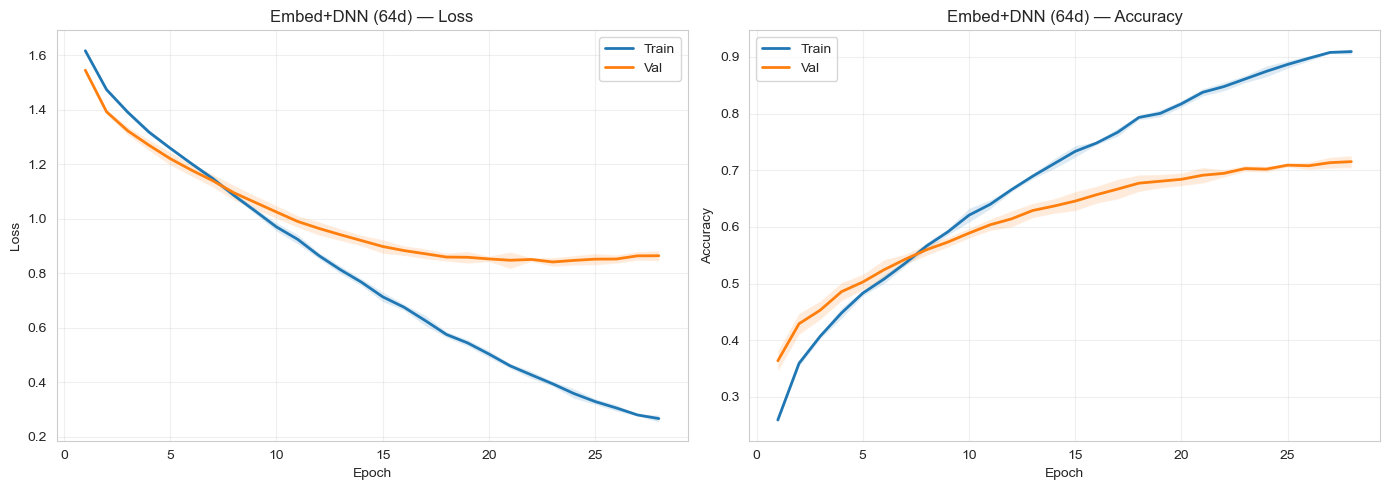


Embed+DNN (128d):
  Fold 1: 67.30%
  Fold 2: 68.30%
  Fold 3: 70.70%
  Fold 4: 70.80%
  Fold 5: 68.60%
  → 69.14% ± 1.38%


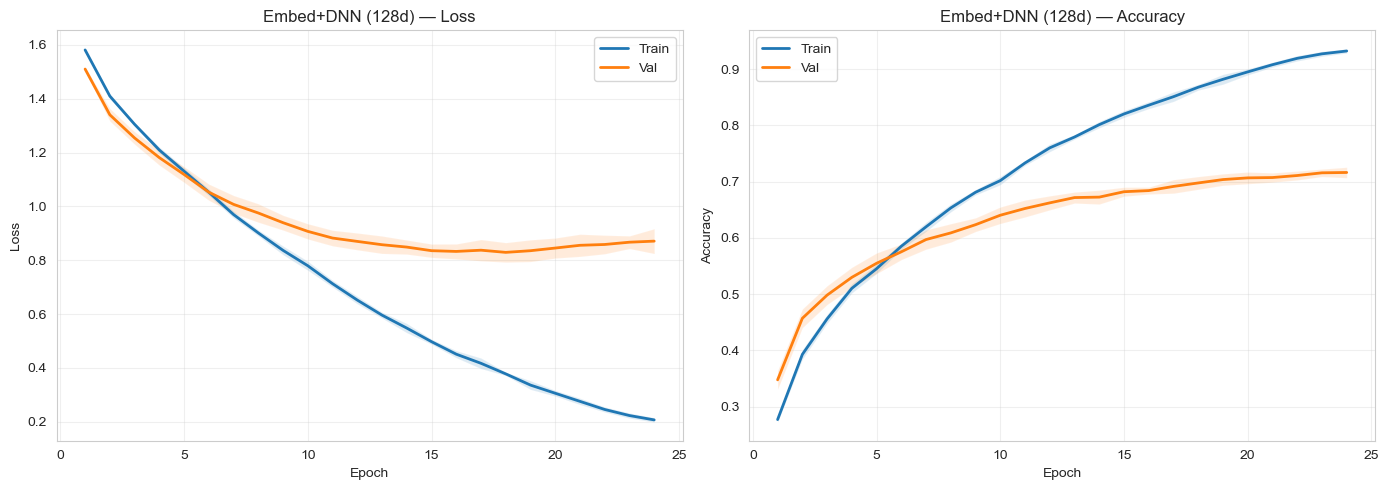


BiLSTM (h=64):
  Fold 1: 65.20%
  Fold 2: 59.50%
  Fold 3: 63.60%
  Fold 4: 61.00%
  Fold 5: 51.90%
  → 60.24% ± 4.62%


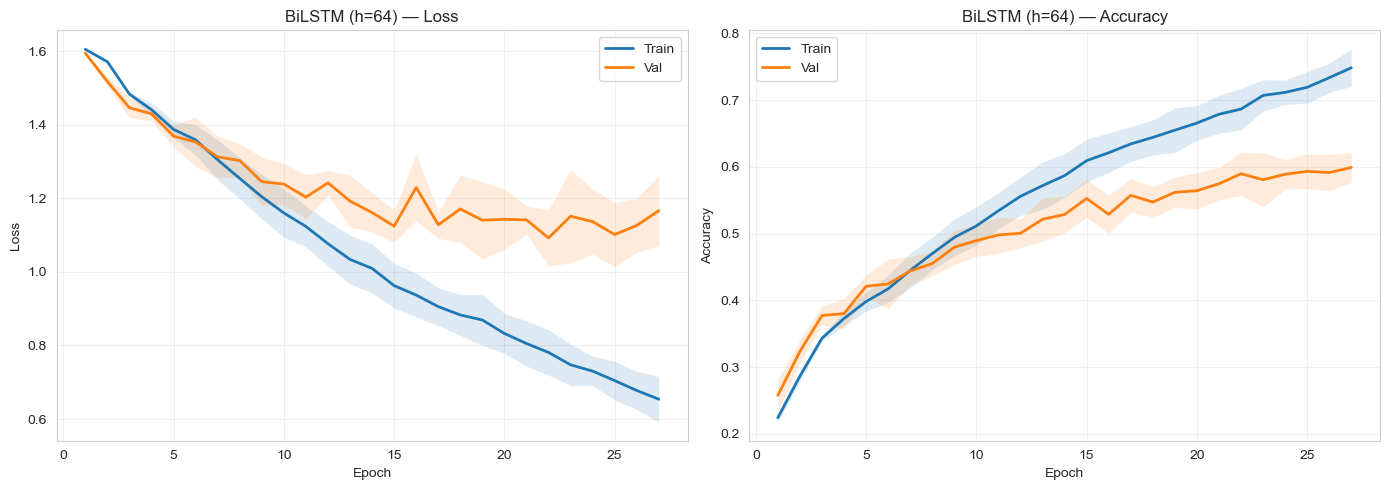


BiLSTM (h=128):
  Fold 1: 58.90%
  Fold 2: 54.80%
  Fold 3: 60.30%
  Fold 4: 65.60%
  Fold 5: 49.10%
  → 57.74% ± 5.53%


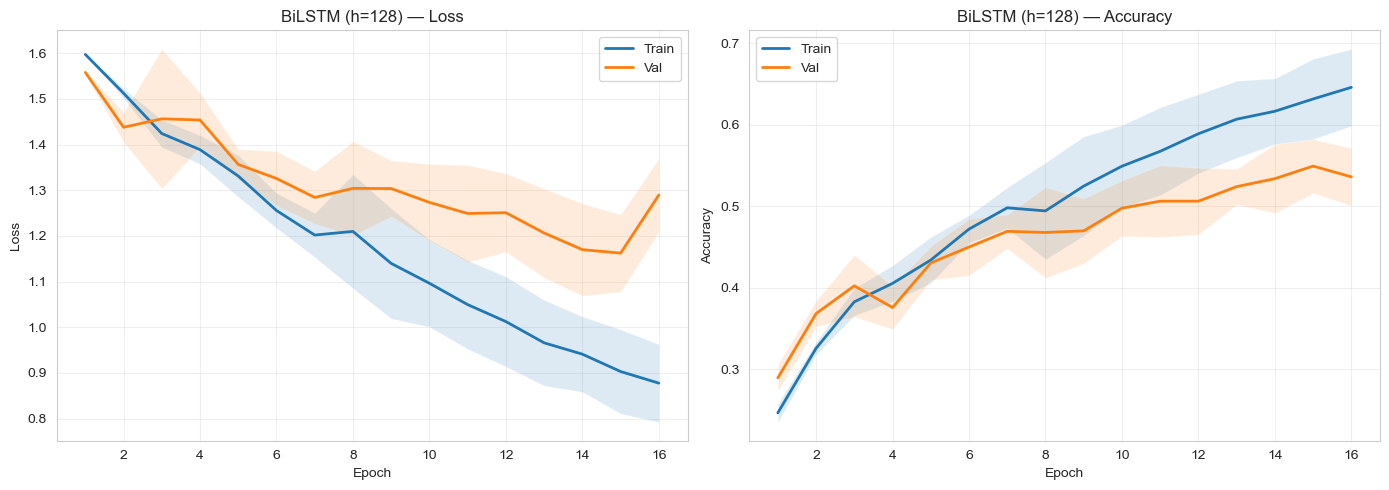


BiGRU (h=64):
  Fold 1: 64.40%
  Fold 2: 64.90%
  Fold 3: 74.00%
  Fold 4: 60.70%
  Fold 5: 67.10%
  → 66.22% ± 4.40%


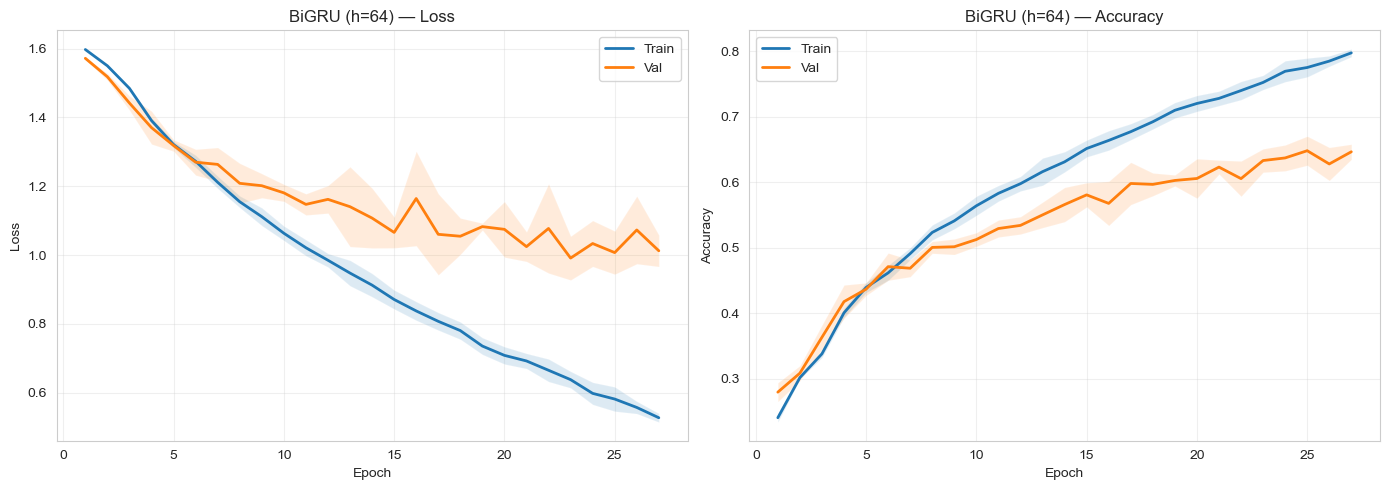


BiGRU (h=128):
  Fold 1: 64.70%
  Fold 2: 68.20%
  Fold 3: 68.60%
  Fold 4: 65.20%
  Fold 5: 65.10%
  → 66.36% ± 1.68%


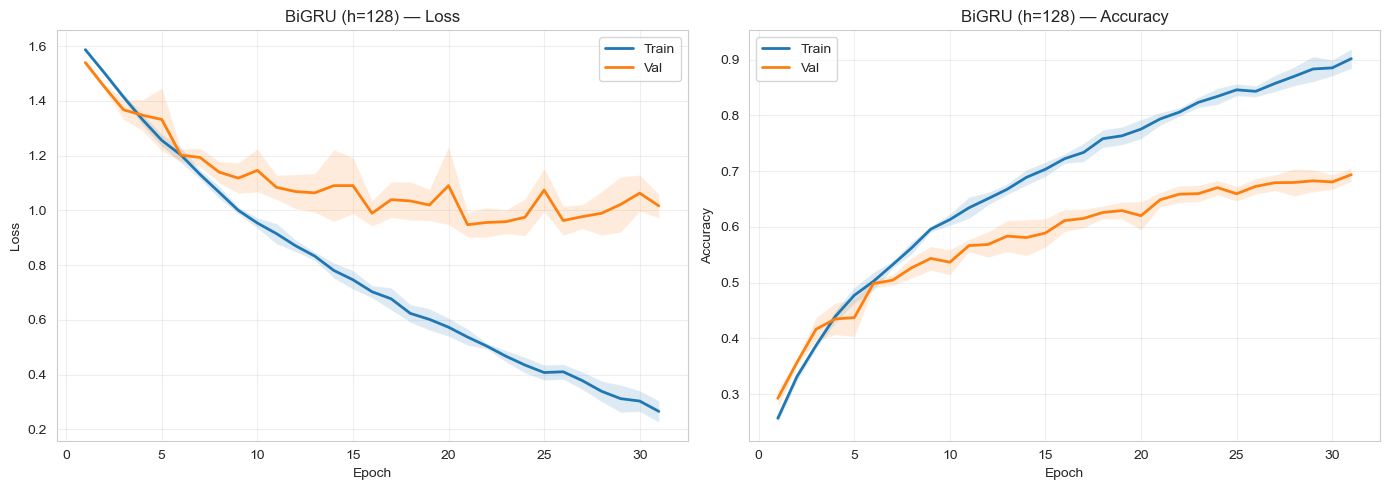


BiLSTM+GloVe (frozen):
    GloVe: 9722/9998
  Fold 1: 73.10%
  Fold 2: 72.70%
  Fold 3: 64.80%
  Fold 4: 73.80%
  Fold 5: 71.90%
  → 71.26% ± 3.29%


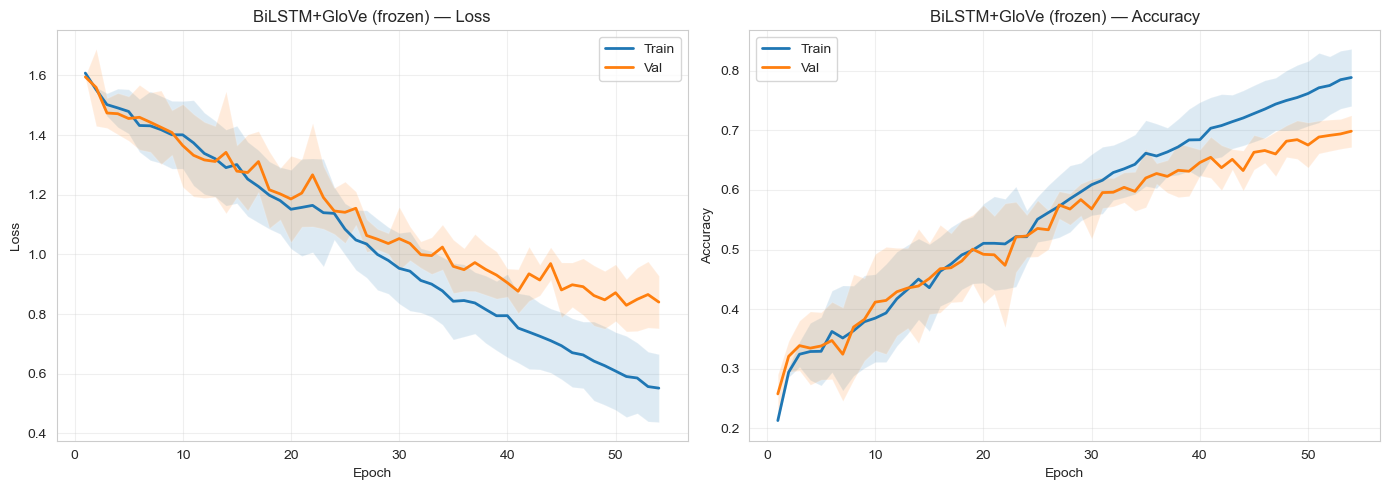


BiLSTM+GloVe (fine-tuned):
    GloVe: 9722/9998
  Fold 1: 62.20%
  Fold 2: 61.70%
  Fold 3: 62.80%
  Fold 4: 61.70%
  Fold 5: 62.50%
  → 62.18% ± 0.44%


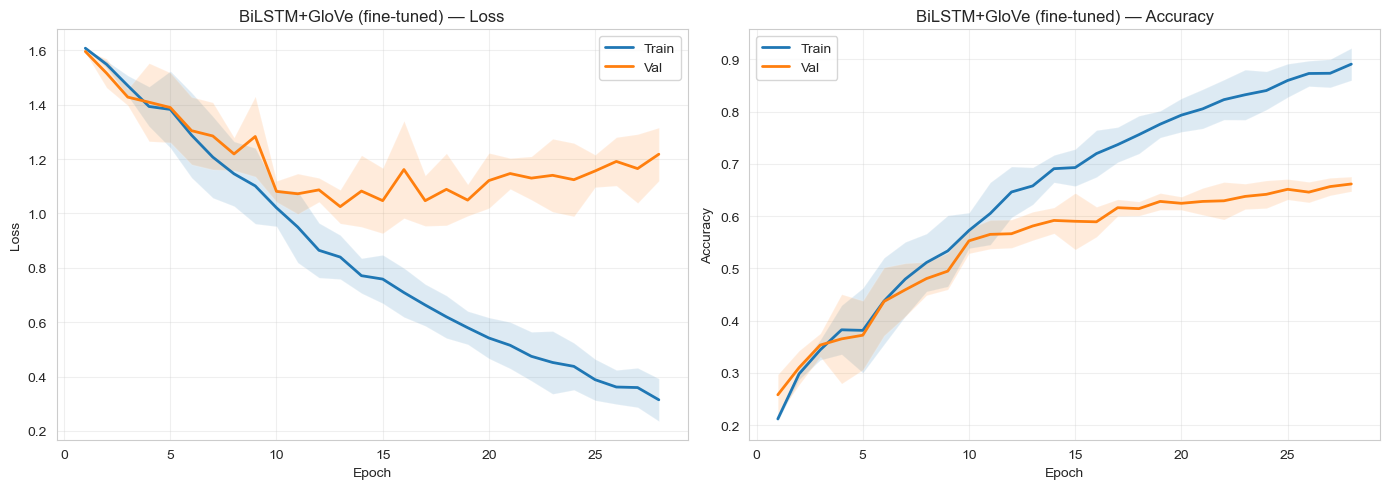

In [28]:
print("=" * 60)
print("Stratified 5-Fold Cross-Validation")
print("=" * 60)
cv_results = {}

# ═══ A) DNNs tabulares ═══
tab_cfgs = {
    'DNN Wide (256→128)':          lambda i, n: DNNWide(i, n),
    'DNN Narrow (128→64)':         lambda i, n: DNNNarrow(i, n),
    'DNN Deep (256→128→64)':       lambda i, n: DNNDeep(i, n),
    'DNN Simple (128→32)':         lambda i, n: DNNSimple(i, n),
    'DNN VeryDeep (256→128→64→32)':lambda i, n: DNNVeryDeep(i, n),
    'DNN LeakyReLU (256→128)':     lambda i, n: DNNLeakyReLU(i, n),
    'DNN ELU (256→128)':           lambda i, n: DNNELU(i, n),
}
for nome, fn in tab_cfgs.items():
    print(f'\n{nome}:')
    accs = []; histories = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        X_tr, _, X_vl, _, _, _ = prepare_fold_data(t_tr, l_tr, t_vl, l_vl, **FEAT_PARAMS)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc, hist = train_pytorch(fn(X_tr.shape[1], num_classes),
            torch.FloatTensor(X_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.FloatTensor(X_vl).to(device), torch.LongTensor(y_vl).to(device))
        accs.append(acc); histories.append(hist)
        print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')
    plot_training_curves(nome, histories)

# ═══ B) Embedding+DNN ═══
kfold_seq('Embed+DNN (64d)',  lambda vs, nc: EmbeddingDNN(vs, 64, nc))
kfold_seq('Embed+DNN (128d)', lambda vs, nc: EmbeddingDNN(vs, 128, nc))

# ═══ C) BiLSTM ═══
kfold_seq('BiLSTM (h=64)',  lambda vs, nc: BiLSTM(vs, 64, 64, nc))
kfold_seq('BiLSTM (h=128)', lambda vs, nc: BiLSTM(vs, 64, 128, nc))

# ═══ D) BiGRU ═══
kfold_seq('BiGRU (h=64)',  lambda vs, nc: BiGRU(vs, 64, 64, nc))
kfold_seq('BiGRU (h=128)', lambda vs, nc: BiGRU(vs, 64, 128, nc))

# ═══ E) BiLSTM+GloVe ═══
for nome, freeze in [('BiLSTM+GloVe (frozen)', True), ('BiLSTM+GloVe (fine-tuned)', False)]:
    print(f'\n{nome}:')
    accs = []; histories = []
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        w2i = build_fold_vocab(t_tr)
        emb, found = build_emb_matrix(w2i, glove_all, GLOVE_DIM)
        if fold == 0: print(f'    GloVe: {found}/{len(w2i)-2}')
        s_tr = texts_to_sequences(t_tr, w2i, MAX_SEQ_LEN)
        s_vl = texts_to_sequences(t_vl, w2i, MAX_SEQ_LEN)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        torch.manual_seed(42)
        acc, hist = train_pytorch(
            BiLSTMGloVe(emb, GLOVE_HIDDEN, num_classes, freeze_embed=freeze),
            torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl).to(device),
            wd=1e-4, patience=15)
        accs.append(acc); histories.append(hist)
        print(f'  Fold {fold+1}: {acc:.2%}')
    cv_results[nome] = np.array(accs)
    print(f'  → {np.mean(accs):.2%} ± {np.std(accs):.2%}')
    plot_training_curves(nome, histories)


In [29]:
rows = []
for nome, accs in cv_results.items():
    rows.append({'Modelo': nome, 'Média': f'{accs.mean():.2%}',
                 'Std': f'±{accs.std():.2%}', 'Min': f'{accs.min():.2%}', 'Max': f'{accs.max():.2%}'})
df_cv = pd.DataFrame(rows).sort_values('Média', ascending=False)
print('\n' + '=' * 60)
print('RESUMO K-FOLD CV')
print('=' * 60)
print(df_cv.to_string(index=False))


RESUMO K-FOLD CV
                      Modelo  Média    Std    Min    Max
     DNN LeakyReLU (256→128) 85.16% ±0.86% 84.30% 86.70%
          DNN Wide (256→128) 84.74% ±0.88% 83.10% 85.60%
         DNN Narrow (128→64) 84.60% ±0.94% 83.40% 85.70%
         DNN Simple (128→32) 84.44% ±1.09% 83.30% 85.90%
       DNN Deep (256→128→64) 84.24% ±0.67% 83.20% 85.00%
DNN VeryDeep (256→128→64→32) 84.02% ±1.10% 83.00% 85.60%
           DNN ELU (256→128) 83.98% ±0.95% 83.00% 85.70%
       BiLSTM+GloVe (frozen) 71.26% ±3.29% 64.80% 73.80%
             Embed+DNN (64d) 69.66% ±1.25% 67.90% 71.50%
            Embed+DNN (128d) 69.14% ±1.38% 67.30% 70.80%
               BiGRU (h=128) 66.36% ±1.68% 64.70% 68.60%
                BiGRU (h=64) 66.22% ±4.40% 60.70% 74.00%
   BiLSTM+GloVe (fine-tuned) 62.18% ±0.44% 61.70% 62.80%
               BiLSTM (h=64) 60.24% ±4.62% 51.90% 65.20%
              BiLSTM (h=128) 57.74% ±5.53% 49.10% 65.60%


## GridSearch do melhor modelo

Grid Search 5-Fold — 27 configs × 5 folds = 135 treinos
  [ 1/27] Adam | lr=0.01 | drop=0.3  →  82.42% ± 0.89%  [⏱ 1.1min | ETA: 29.7min]
  [ 2/27] Adam | lr=0.01 | drop=0.5  →  83.76% ± 1.02%  [⏱ 2.3min | ETA: 29.2min]
  [ 3/27] Adam | lr=0.01 | drop=0.7  →  84.50% ± 1.29%  [⏱ 3.6min | ETA: 28.8min]
  [ 4/27] Adam | lr=0.001 | drop=0.3  →  84.34% ± 0.99%  [⏱ 4.7min | ETA: 26.8min]
  [ 5/27] Adam | lr=0.001 | drop=0.5  →  84.98% ± 0.76%  [⏱ 5.7min | ETA: 25.2min]
  [ 6/27] Adam | lr=0.001 | drop=0.7  →  84.82% ± 1.12%  [⏱ 6.8min | ETA: 23.8min]
  [ 7/27] Adam | lr=0.0001 | drop=0.3  →  85.08% ± 1.11%  [⏱ 8.0min | ETA: 22.8min]
  [ 8/27] Adam | lr=0.0001 | drop=0.5  →  85.12% ± 0.92%  [⏱ 9.2min | ETA: 21.8min]
  [ 9/27] Adam | lr=0.0001 | drop=0.7  →  85.56% ± 0.80%  [⏱ 10.6min | ETA: 21.1min]
  [10/27] AdamW | lr=0.01 | drop=0.3  →  83.02% ± 1.14%  [⏱ 11.6min | ETA: 19.8min]
  [11/27] AdamW | lr=0.01 | drop=0.5  →  83.08% ± 0.84%  [⏱ 12.7min | ETA: 18.4min]
  [12/27] AdamW | lr=0.01 | 

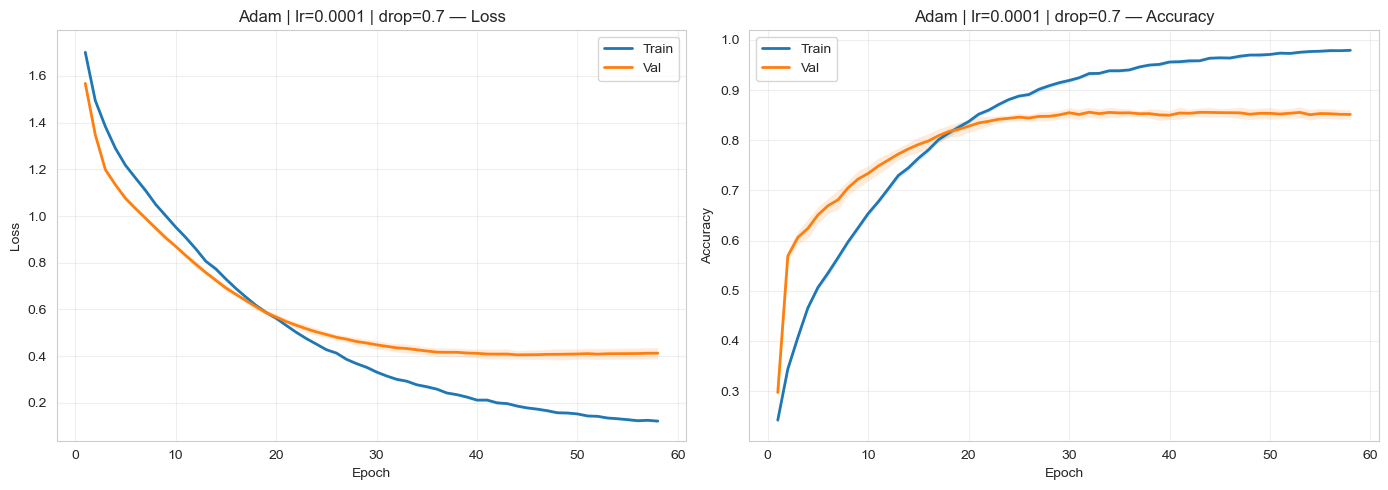

In [31]:
# ══════════════════════════════════════════════════════════════
# Grid Search 5-Fold — Optimizer × LR × Dropout
# ══════════════════════════════════════════════════════════════

class DNNGrid(nn.Module):
    """256 → 128 → classes (LeakyReLU, dropout parameterizado)""" #Uma vez que foi o melhor modelo a ser encontrado anteriormente
    def __init__(self, input_size, num_classes, drop=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(drop),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.1), nn.Dropout(drop),
            nn.Linear(128, num_classes))
    def forward(self, x): return self.net(x)


def train_grid(model, X_tr, y_tr, X_vl, y_vl,
               opt_name='Adam', lr=0.001, wd=1e-3, epochs=100, patience=10, bs=128):
    model = model.to(device)
    crit = nn.CrossEntropyLoss()
    if opt_name == 'Adam':
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt_name == 'AdamW':
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    else:
        opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=5)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=bs, shuffle=True)
    best_vl = float('inf'); wait = 0; best_st = None
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    for ep in range(epochs):
        model.train()
        ep_loss = 0; ep_correct = 0; ep_total = 0
        for bx, by in loader:
            opt.zero_grad()
            out = model(bx)
            loss = crit(out, by)
            loss.backward(); opt.step()
            ep_loss += loss.item() * bx.size(0)
            ep_correct += (torch.argmax(out, 1) == by).sum().item()
            ep_total += bx.size(0)
        history['train_loss'].append(ep_loss / ep_total)
        history['train_acc'].append(ep_correct / ep_total)
        model.eval()
        with torch.no_grad():
            val_out = model(X_vl)
            vl = crit(val_out, y_vl).item()
            va = (torch.argmax(val_out, 1) == y_vl).float().mean().item()
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        sched.step(vl)
        if vl < best_vl:
            best_vl = vl; wait = 0
            best_st = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_st: model.load_state_dict(best_st)
    model.eval()
    with torch.no_grad():
        final_acc = (torch.argmax(model(X_vl), 1) == y_vl).float().mean().item()
    return final_acc, history

# --- Grid Search com K-Fold e tempo estimado ---
optimizers = ['Adam', 'AdamW', 'SGD']
lrs = [0.01, 0.001, 0.0001]
dropouts = [0.3, 0.5, 0.7]

configs = [(o, l, d) for o in optimizers for l in lrs for d in dropouts]
total_configs = len(configs)
total_runs = total_configs * K

print("=" * 60)
print(f"Grid Search 5-Fold — {total_configs} configs × {K} folds = {total_runs} treinos")
print("=" * 60)

results = []
global_start = time.time()
run_count = 0

for cfg_idx, (opt_name, lr, drop) in enumerate(configs):
    config_str = f'{opt_name} | lr={lr} | drop={drop}'
    accs = []; all_hist = []
    
    for fold, (tr_i, vl_i) in enumerate(stratified_k_fold(labels, K)):
        run_count += 1
        t_tr = [textos[i] for i in tr_i]; t_vl = [textos[i] for i in vl_i]
        l_tr = [labels[i] for i in tr_i]; l_vl = [labels[i] for i in vl_i]
        X_tr, _, X_vl, _, _, _ = prepare_fold_data(t_tr, l_tr, t_vl, l_vl, **FEAT_PARAMS)
        y_tr = np.array([class_names_list.index(l) for l in l_tr])
        y_vl = np.array([class_names_list.index(l) for l in l_vl])
        
        torch.manual_seed(42)
        model = DNNGrid(X_tr.shape[1], num_classes, drop=drop)
        acc, hist = train_grid(model,
            torch.FloatTensor(X_tr).to(device), torch.LongTensor(y_tr).to(device),
            torch.FloatTensor(X_vl).to(device), torch.LongTensor(y_vl).to(device),
            opt_name=opt_name, lr=lr, patience=15)
        accs.append(acc); all_hist.append(hist)
    
    mean_acc = np.mean(accs); std_acc = np.std(accs)
    results.append({'config': config_str, 'mean': mean_acc, 'std': std_acc,
                    'accs': accs, 'histories': all_hist,
                    'opt': opt_name, 'lr': lr, 'drop': drop})
    
    # --- Tempo decorrido e estimativa ---
    elapsed = time.time() - global_start
    avg_per_run = elapsed / run_count
    remaining_runs = total_runs - run_count
    eta = avg_per_run * remaining_runs
    
    elapsed_min = elapsed / 60
    eta_min = eta / 60
    
    print(f'  [{cfg_idx+1:2d}/{total_configs}] {config_str}  →  '
          f'{mean_acc:.2%} ± {std_acc:.2%}  '
          f'[⏱ {elapsed_min:.1f}min | ETA: {eta_min:.1f}min]')

# --- Ranking final ---
results.sort(key=lambda x: x['mean'], reverse=True)
total_time = (time.time() - global_start) / 60

print(f'\n{"=" * 60}')
print(f'  RANKING TOP 10  (tempo total: {total_time:.1f} min)')
print(f'{"=" * 60}')
for i, r in enumerate(results[:10]):
    marker = ' 🏆' if i == 0 else ''
    print(f'  {i+1:2d}. {r["config"]}  →  {r["mean"]:.2%} ± {r["std"]:.2%}{marker}')

# --- Plot do melhor ---
best = results[0]
print(f'\n✅ Melhor: {best["config"]} ({best["mean"]:.2%} ± {best["std"]:.2%})')

min_len = min(len(h['train_loss']) for h in best['histories'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (tk, vk), ax, title in [
    (('train_loss', 'val_loss'), axes[0], 'Loss'),
    (('train_acc', 'val_acc'), axes[1], 'Accuracy')
]:
    t_vals = np.array([h[tk][:min_len] for h in best['histories']])
    v_vals = np.array([h[vk][:min_len] for h in best['histories']])
    epochs_range = range(1, min_len + 1)
    ax.plot(epochs_range, t_vals.mean(axis=0), label='Train', linewidth=2)
    ax.plot(epochs_range, v_vals.mean(axis=0), label='Val', linewidth=2)
    ax.fill_between(epochs_range,
                    t_vals.mean(0) - t_vals.std(0),
                    t_vals.mean(0) + t_vals.std(0), alpha=0.15)
    ax.fill_between(epochs_range,
                    v_vals.mean(0) - v_vals.std(0),
                    v_vals.mean(0) + v_vals.std(0), alpha=0.15)
    ax.set_xlabel('Epoch'); ax.set_ylabel(title)
    ax.set_title(f'{best["config"]} — {title}')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Guardar o melhor no cv_results para a tabela final
cv_results[f'Grid Best: {best["config"]}'] = np.array(best['accs'])


### **5. Retreino do Melhor Modelo + Avaliação no Teste**

In [34]:
# ═══════════════════════════════════════════════════════════════
# 5. Retreino do Melhor Modelo + Avaliação no Teste
# ═══════════════════════════════════════════════════════════════

X_train, Y_train_oh, X_val, Y_val_oh, transformers, encoder = prepare_text_data(
    textos, labels, max_features=1500, char_features=1500, val_size=0.20,
    use_stratify=True, ngram_range=(1, 2), stop_words=set())
X_test = transform_new_texts(textos_test, transformers)
Y_test_oh = encoder.transform(np.array(labels_test))
y_train = np.argmax(Y_train_oh, axis=1); y_val = np.argmax(Y_val_oh, axis=1)
y_test = np.argmax(Y_test_oh, axis=1)
class_names = encoder.classes; input_size = X_train.shape[1]

# Reconstruir df_cv com resultados do Grid Search incluídos
rows = []
for nome, accs in cv_results.items():
    rows.append({'Modelo': nome, 'Média': f'{accs.mean():.2%}',
                 'Std': f'±{accs.std():.2%}', 'Mean_num': accs.mean()})
df_cv = pd.DataFrame(rows).sort_values('Mean_num', ascending=False)
print('Top 5 modelos (incluindo Grid Search):')
print(df_cv[['Modelo', 'Média', 'Std']].head().to_string(index=False))

melhor_nome = df_cv.iloc[0]['Modelo']
print(f'\nMelhor modelo: {melhor_nome}')

# --- Mapas de modelos ---
tab_map = {
    'DNN Wide (256→128)':           DNNWide,
    'DNN Narrow (128→64)':          DNNNarrow,
    'DNN Deep (256→128→64)':        DNNDeep,
    'DNN Simple (128→32)':          DNNSimple,
    'DNN VeryDeep (256→128→64→32)': DNNVeryDeep,
    'DNN LeakyReLU (256→128)':      DNNLeakyReLU,
    'DNN ELU (256→128)':            DNNELU,
}

# --- Verificar se o melhor veio do Grid Search ---
is_grid = melhor_nome.startswith('Grid Best:')
grid_opt = 'Adam'
grid_lr = 0.001
grid_drop = 0.5

if is_grid:
    # Extrair hiperparâmetros do nome: "Grid Best: AdamW | lr=0.001 | drop=0.3"
    for r in results:
        if r['config'] in melhor_nome:
            grid_opt = r['opt']
            grid_lr = r['lr']
            grid_drop = r['drop']
            break
    print(f'  Hiperparâmetros: opt={grid_opt}, lr={grid_lr}, drop={grid_drop}')

if melhor_nome in tab_map or is_grid:
    X_tr_t = torch.FloatTensor(X_train).to(device); y_tr_t = torch.LongTensor(y_train).to(device)
    X_vl_t = torch.FloatTensor(X_val).to(device); y_vl_t = torch.LongTensor(y_val).to(device)
    X_te_t = torch.FloatTensor(X_test).to(device); y_te_t = torch.LongTensor(y_test).to(device)
    torch.manual_seed(42)
    
    if is_grid:
        melhor_model = DNNGrid(input_size, num_classes, drop=grid_drop).to(device)
    else:
        melhor_model = tab_map[melhor_nome](input_size, num_classes).to(device)
    
    t0 = time.time()
    if is_grid:
        _, _ = train_grid(melhor_model, X_tr_t, y_tr_t, X_vl_t, y_vl_t,
                          opt_name=grid_opt, lr=grid_lr, patience=15)
    else:
        _, _ = train_pytorch(melhor_model, X_tr_t, y_tr_t, X_vl_t, y_vl_t, patience=10)
    tempo = time.time() - t0
    
    melhor_model.eval()
    with torch.no_grad():
        train_acc = (torch.argmax(melhor_model(X_tr_t), 1) == y_tr_t).float().mean().item()
        val_acc = (torch.argmax(melhor_model(X_vl_t), 1) == y_vl_t).float().mean().item()
        test_acc = (torch.argmax(melhor_model(X_te_t), 1) == y_te_t).float().mean().item()
    test_input = X_te_t; test_labels = y_te_t; is_tabular = True

else:
    from utils import train_test_split
    t_tr, t_vl, l_tr, l_vl = train_test_split(textos, labels, test_size=0.20, random_state=42, stratify=labels)
    word2idx = build_fold_vocab(t_tr); actual_vocab_size = len(word2idx)
    s_tr = texts_to_sequences(t_tr, word2idx, MAX_SEQ_LEN)
    s_vl = texts_to_sequences(t_vl, word2idx, MAX_SEQ_LEN)
    s_te = texts_to_sequences(textos_test, word2idx, MAX_SEQ_LEN)
    y_tr_s = np.array([list(class_names).index(l) for l in l_tr])
    y_vl_s = np.array([list(class_names).index(l) for l in l_vl])
    y_te_s = np.array([list(class_names).index(l) for l in labels_test])

    torch.manual_seed(42)
    seq_map = {
        'Embed+DNN (64d)':  lambda: EmbeddingDNN(actual_vocab_size, 64, num_classes),
        'Embed+DNN (128d)': lambda: EmbeddingDNN(actual_vocab_size, 128, num_classes),
        'BiLSTM (h=64)':  lambda: BiLSTM(actual_vocab_size, 64, 64, num_classes),
        'BiLSTM (h=128)': lambda: BiLSTM(actual_vocab_size, 64, 128, num_classes),
        'BiGRU (h=64)':   lambda: BiGRU(actual_vocab_size, 64, 64, num_classes),
        'BiGRU (h=128)':  lambda: BiGRU(actual_vocab_size, 64, 128, num_classes),
    }
    glove_map = {'BiLSTM+GloVe (frozen)': True, 'BiLSTM+GloVe (fine-tuned)': False}

    if melhor_nome in seq_map:
        melhor_model = seq_map[melhor_nome]()
    elif melhor_nome in glove_map:
        emb, _ = build_emb_matrix(word2idx, glove_all, GLOVE_DIM)
        melhor_model = BiLSTMGloVe(emb, GLOVE_HIDDEN, num_classes, freeze_embed=glove_map[melhor_nome])
    else:
        raise ValueError(f'Modelo desconhecido: {melhor_nome}')

    t0 = time.time()
    _, _ = train_pytorch(melhor_model,
        torch.LongTensor(s_tr).to(device), torch.LongTensor(y_tr_s).to(device),
        torch.LongTensor(s_vl).to(device), torch.LongTensor(y_vl_s).to(device),
        wd=1e-4, patience=15)
    tempo = time.time() - t0
    melhor_model.eval()
    te_t = torch.LongTensor(s_te).to(device); yte_t = torch.LongTensor(y_te_s).to(device)
    with torch.no_grad():
        train_acc = (torch.argmax(melhor_model(torch.LongTensor(s_tr).to(device)), 1) == torch.LongTensor(y_tr_s).to(device)).float().mean().item()
        val_acc = (torch.argmax(melhor_model(torch.LongTensor(s_vl).to(device)), 1) == torch.LongTensor(y_vl_s).to(device)).float().mean().item()
        test_acc = (torch.argmax(melhor_model(te_t), 1) == yte_t).float().mean().item()
    test_input = te_t; test_labels = yte_t; is_tabular = False

print(f'\n🏆 {melhor_nome}: Train {train_acc:.2%} | Val {val_acc:.2%} | Test {test_acc:.2%} | {tempo:.1f}s')


### **6. Avaliação Final**

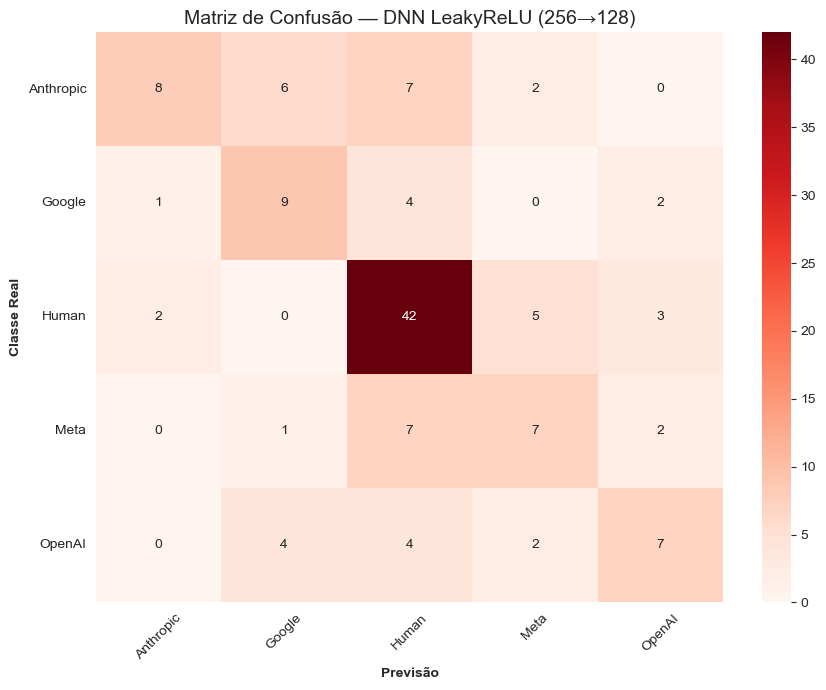


Classification Report — DNN LeakyReLU (256→128):
              precision    recall  f1-score   support

   Anthropic       0.73      0.35      0.47        23
      Google       0.45      0.56      0.50        16
       Human       0.66      0.81      0.72        52
        Meta       0.44      0.41      0.42        17
      OpenAI       0.50      0.41      0.45        17

    accuracy                           0.58       125
   macro avg       0.55      0.51      0.51       125
weighted avg       0.59      0.58      0.57       125



In [35]:
melhor_model.eval()
with torch.no_grad(): _, predicted = torch.max(melhor_model(test_input), 1)
y_true = test_labels.cpu().numpy(); y_pred = predicted.cpu().numpy()
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão', fontweight='bold'); plt.ylabel('Classe Real', fontweight='bold')
plt.title(f'Matriz de Confusão — {melhor_nome}', fontsize=14)
plt.xticks(rotation=45); plt.yticks(rotation=0); plt.tight_layout(); plt.show()
print(f'\nClassification Report — {melhor_nome}:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

### **7. Guardar o Modelo**

In [37]:
import pickle
os.makedirs('../models', exist_ok=True)
torch.save(melhor_model.state_dict(), '../models/pytorch.pth')
meta = {'model_class': melhor_model.__class__.__name__, 'input_size': input_size,
        'num_classes': num_classes, 'class_names': list(class_names),
        'transformers': transformers, 'encoder': encoder}
# Se for DNNGrid, guardar hiperparâmetros do Grid Search
if is_grid:
    meta['grid_opt'] = grid_opt
    meta['grid_lr'] = grid_lr
    meta['grid_drop'] = grid_drop
if not is_tabular:
    meta['word2idx'] = word2idx; meta['max_seq_len'] = MAX_SEQ_LEN
    meta['vocab_size'] = actual_vocab_size
    if 'GloVe' in melhor_nome:
        meta['embed_dim'] = GLOVE_DIM; meta['hidden_dim'] = GLOVE_HIDDEN
        meta['embedding_matrix'] = emb; meta['freeze_embed'] = glove_map[melhor_nome]
    elif 'Embed' in melhor_nome:
        meta['embed_dim'] = 128 if '128' in melhor_nome else 64
    else:
        meta['embed_dim'] = 64
        meta['hidden_dim'] = 128 if '128' in melhor_nome else 64
with open('../models/pytorch.pkl', 'wb') as f: pickle.dump(meta, f)
print(f'✅ Modelo guardado: {meta["model_class"]}')